In [142]:
library(rsample)     # data splitting 
library(dplyr)       # data wrangling
library(rpart)       # performing regression trees
library(rpart.plot)  # plotting regression trees
library(ipred)       # bagging
library(caret)       # bagging
library(tidyverse)

In [143]:
set.seed(123)
merged <- read_csv("data/merged_data.csv")
split <- initial_split(merged, prop = 0.75)
train <- training(split)
test  <- testing(split)


Rows: 254 Columns: 404
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (1): County
dbl (380): cve, outbreak, enrollment, PHR, pct_hispanic, pct_black, pct_whit...
lgl  (23): median_income, Advised to Cut Down Salt - Do not use salt, Diabet...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [144]:
library(rpart)

# 1. Drop non-numeric / ID columns
train_model <- train[, !names(train) %in% c("County")]

# 2. Sanitize column names — this is the key fix
names(train_model) <- make.names(names(train_model), unique = TRUE)

# 3. Fit the tree
fit <- rpart(outbreak ~ ., data = train_model, method = "anova")



In [145]:
fit

n= 190 

node), split, n, deviance, yval
      * denotes terminal node

1) root 190 174985.40  3.247368  
  2) pct_uninsured< 27.25 183   5368.23  1.098361 *
  3) pct_uninsured>=27.25 7 146677.70 59.428570 *

In [146]:
set.seed(123)
merged <- read_csv("data/merged_data.csv")
ames_split <- initial_split(merged, prop = 0.75)
ames_train <- training(ames_split)
ames_test  <- testing(ames_split)

Rows: 254 Columns: 404
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (1): County
dbl (380): cve, outbreak, enrollment, PHR, pct_hispanic, pct_black, pct_whit...
lgl  (23): median_income, Advised to Cut Down Salt - Do not use salt, Diabet...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [147]:
library(rpart)

# 1. Drop non-numeric / ID columns
merged_model <- merged[, !names(merged) %in% c("County")]

# 2. Sanitize column names — this is the key fix
names(merged_model) <- make.names(names(merged_model), unique = TRUE)

# 3. Fit the tree
fit <- rpart(outbreak ~ ., data = merged_model, method = "anova", control = rpart.control(minsplit = 10, cp = 0.005))
fit

n= 254 

node), split, n, deviance, yval
      * denotes terminal node

 1) root 254 181165.6000   2.9251970  
   2) pct_uninsured< 30.2 251  11511.7600   1.3107570  
     4) Pap...HPV.Test.Past.5.Yrs.21...No< 64.15 204   1086.8380   0.3970588 *
     5) Pap...HPV.Test.Past.5.Yrs.21...No>=64.15 47   9515.4040   5.2765960  
      10) enrollment< 22145 44   4217.6360   3.0909090  
        20) pct_uninsured< 26.25 41    750.1951   1.4634150 *
        21) pct_uninsured>=26.25 3   1874.6670  25.3333300 *
      11) enrollment>=22145 3   2004.6670  37.3333300 *
   3) pct_uninsured>=30.2 3 114264.0000 138.0000000 *

In [148]:
hyper_grid <- expand.grid(
  minsplit = seq(5, 20, 1),
  maxdepth = seq(8, 15, 1)
)

head(hyper_grid)

nrow(hyper_grid)

,minsplit,maxdepth
,<dbl>,<dbl>
1,5,8
2,6,8
3,7,8
4,8,8
5,9,8
6,10,8


[1] 128

In [149]:

models <- list()

for (i in 1:nrow(hyper_grid)) {
  
  # get minsplit, maxdepth values at row i
  minsplit <- hyper_grid$minsplit[i]
  maxdepth <- hyper_grid$maxdepth[i]

  # train a model and store in the list
  models[[i]] <- rpart(
    formula = outbreak ~ .,
    data    = train_model,
    method  = "anova",
    control = list(minsplit = minsplit, maxdepth = maxdepth)
    )
}

In [156]:
get_cp <- function(x) {
  min    <- which.min(x$cptable[, "xerror"])
  cp <- x$cptable[min, "CP"] 
}

# function to get minimum error
get_min_error <- function(x) {
  min    <- which.min(x$cptable[, "xerror"])
  xerror <- x$cptable[min, "xerror"] 
}

hyper_grid %>%
  mutate(
    cp    = purrr::map_dbl(models, get_cp),
    error = purrr::map_dbl(models, get_min_error)
    ) %>%
  arrange(error) %>%
  top_n(-5, wt = error)

minsplit,maxdepth,cp,error
<dbl>,<dbl>,<dbl>,<dbl>
7,13,0.0100000,1.005748
7,15,0.4795462,1.009897
8,13,0.3163050,1.009972
6,14,0.4795462,1.009991
13,14,0.2370346,1.010009


In [157]:
# Make data input into predict
test_model <- test[, !names(test) %in% c("County")]
names(test_model) <- make.names(names(test_model), unique = TRUE)

optimal_tree <- rpart(
    formula = outbreak ~ .,
    data    = train_model,
    method  = "anova",
    control = list(minsplit = 7, maxdepth = 13, cp = 0.0100000)
    )
optimal_tree
pred <- predict(optimal_tree, newdata = test_model)
RMSE(pred = pred, obs = test_model$outbreak)
#pred

n= 190 

node), split, n, deviance, yval
      * denotes terminal node

1) root 190 174985.400   3.247368  
  2) cve< 10.235 188   5373.803   1.079787 *
  3) cve>=10.235 2  85698.000 207.000000 *

[1] 9.804745

In [152]:
# WIP -----------------------------

# Load required libraries
library(tree)
library(ISLR)

# Set seed for reproducibility
set.seed(2)

# Remove the 'County' column FIRST, before sampling
merged_clean <- merged[, !names(merged) %in% c("County")]

#tree=tree(outbreak ~ . -County , merged ,subset=merged)


# other WIP-------------------------------


In [153]:

library(smotefamily)

set.seed(123)
merged <- read_csv("data/merged_data.csv")
split <- initial_split(merged, prop = 0.75)
train <- training(split)
test  <- testing(split)
train <- train[, !names(train) %in% c("County")]
train <- na.omit(train)
train_smote <- train[, colSums(is.na(train)) == 0]
non_num_cols <- names(train_smote)[!sapply(train_smote, is.numeric) & 
                                    names(train_smote) != "outbreak"]

sapply(train_smote[non_num_cols], function(x) any(x == "NA", na.rm = TRUE))

names(train_smote)[!sapply(train_smote, is.numeric)]

smote_output <- SMOTE(X = train_smote[, names(train_smote) != "outbreak"],
                      target = train_smote$outbreak)


Rows: 254 Columns: 404
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (1): County
dbl (380): cve, outbreak, enrollment, PHR, pct_hispanic, pct_black, pct_whit...
lgl  (23): median_income, Advised to Cut Down Salt - Do not use salt, Diabet...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


median_income 
                                        FALSE 
   Advised to Cut Down Salt - Do not use salt 
                                        FALSE 
                 Diabetes Affected Feet - Yes 
                                        FALSE 
           Diabetes Age - 40 years or younger 
                                        FALSE 
                      Diabetes Age - 41 to 64 
                                        FALSE 
             Diabetes Age - 65 years or older 
                                        FALSE 
                      Diabetes Education - No 
                                        FALSE 
                           Diabetes Test - No 
                                        FALSE 
                          Diabetes Test - Yes 
                                        FALSE 
    DurationClnscpySgmy - 5 or more years ago 
                                        FALSE 
DurationClnscpySgmy - Within the past 2 years 
                                        FALSE 
DurationClnscpySgmy - Within the past 3 years 
                                        FALSE 
DurationClnscpySgmy - Within the past 5 years 
                                        FALSE 
   DurationClnscpySgmy - Within the past year 
                                        FALSE 
        Flu Vaccine Location - Canada\nMexico 
                                        FALSE 
                Flu Vaccine Location - School 
                                        FALSE 
           Last Smoked - Within past 3 months 
                                        FALSE 
               Last Smoked - Within past year 
                                        FALSE 
         Pre-Diabetes - Yes, during pregnancy 
                                        FALSE 
           Sigm and Blood Stool 50-75 I - Yes 
                                        FALSE 
           Sigm and Blood Stool Age 50- - Yes 
                                        FALSE 
                        Suicide Attempt - Yes 
                                        FALSE 
                            Transgender - Yes 
                                        FALSE

[1] "median_income"                                
 [2] "Advised to Cut Down Salt - Do not use salt"   
 [3] "Diabetes Affected Feet - Yes"                 
 [4] "Diabetes Age - 40 years or younger"           
 [5] "Diabetes Age - 41 to 64"                      
 [6] "Diabetes Age - 65 years or older"             
 [7] "Diabetes Education - No"                      
 [8] "Diabetes Test - No"                           
 [9] "Diabetes Test - Yes"                          
[10] "DurationClnscpySgmy - 5 or more years ago"    
[11] "DurationClnscpySgmy - Within the past 2 years"
[12] "DurationClnscpySgmy - Within the past 3 years"
[13] "DurationClnscpySgmy - Within the past 5 years"
[14] "DurationClnscpySgmy - Within the past year"   
[15] "Flu Vaccine Location - Canada\nMexico"        
[16] "Flu Vaccine Location - School"                
[17] "Last Smoked - Within past 3 months"           
[18] "Last Smoked - Within past year"               
[19] "Pre-Diabetes - Yes, during pregnancy"         
[20] "Sigm and Blood Stool 50-75 I - Yes"           
[21] "Sigm and Blood Stool Age 50- - Yes"           
[22] "Suicide Attempt - Yes"                        
[23] "Transgender - Yes"

Warning message in min(n_target):
“no non-missing arguments to min; returning Inf”


ERROR: Error in get.knnx(data, query, k, algorithm): Data include NAs


In [171]:
library(tidyverse)
library(rsample)
library(smotefamily)
library(janitor) 

set.seed(123)

# ── 1. Load & Clean Column Names ──────────────────────────────────────────
merged <- read_csv("data/merged_data.csv") |> 
  clean_names() 

# ── 2. Binarize outcome (any outbreak = 1) ─────────────────────────────────
merged$outbreak <- as.integer(merged$outbreak > 0)
table(merged$outbreak)   # check: expect ~37 positives, ~217 negatives

# ── 3. Train/test split ────────────────────────────────────────────────────
split <- initial_split(merged, prop = 0.75, strata = "outbreak")
train <- training(split)
test  <- testing(split)

# ── 4. Drop County and 100%-NA columns ────────────────────────────────────
train <- train[, !names(train) %in% c("county")]
train <- train[, colMeans(is.na(train)) < 0.5]   # drops median_income + 22 others

# ── 5. Impute remaining NAs with column medians ────────────────────────────
train <- train |>
  mutate(across(
    .cols = everything(),
    .fns  = ~ifelse(is.na(.), median(., na.rm = TRUE), .)
  ))

# Verify no NAs remain
stopifnot(sum(is.na(train)) == 0)

# ── 6. Ensure all feature columns are numeric ──────────────────────────────
non_num <- names(train)[!sapply(train, is.numeric) & names(train) != "outbreak"]
if (length(non_num) > 0) {
  train[non_num] <- lapply(train[non_num], as.numeric)
}

cat("Train rows:", nrow(train), "| Cols:", ncol(train), "\n")
cat("Class balance before SMOTE:\n")
print(table(train$outbreak))

# ── 7. SMOTE ───────────────────────────────────────────────────────────────
smote_output <- SMOTE(
  X      = train[, names(train) != "outbreak"],
  target = train$outbreak,
  K      = 5,
  dup_size = 0   # auto-balance
)

train_balanced <- smote_output$data
names(train_balanced)[names(train_balanced) == "class"] <- "outbreak"
train_balanced$outbreak <- as.factor(train_balanced$outbreak)

cat("\nClass balance after SMOTE:\n")
print(table(train_balanced$outbreak))

# ── 8. Mirror same cleaning on test set ───────────────────────────────────
test <- test[, names(test) %in% c(names(train), "outbreak")]
test <- test |>
  mutate(across(
    .cols = -outbreak,
    .fns  = ~ifelse(is.na(.), median(., na.rm = TRUE), .)
  ))
test$outbreak <- as.factor(as.integer(test$outbreak > 0))



Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test


Rows: 254 Columns: 404
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (1): County
dbl (380): cve, outbreak, enrollment, PHR, pct_hispanic, pct_black, pct_whit...
lgl  (23): median_income, Advised to Cut Down Salt - Do not use salt, Diabet...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.



  0   1 
217  37 

Train rows: 189 | Cols: 335 
Class balance before SMOTE:

  0   1 
162  27 

Class balance after SMOTE:

  0   1 
162 162 


      Predicted
Actual  0  1
     0 50  5
     1  5  5


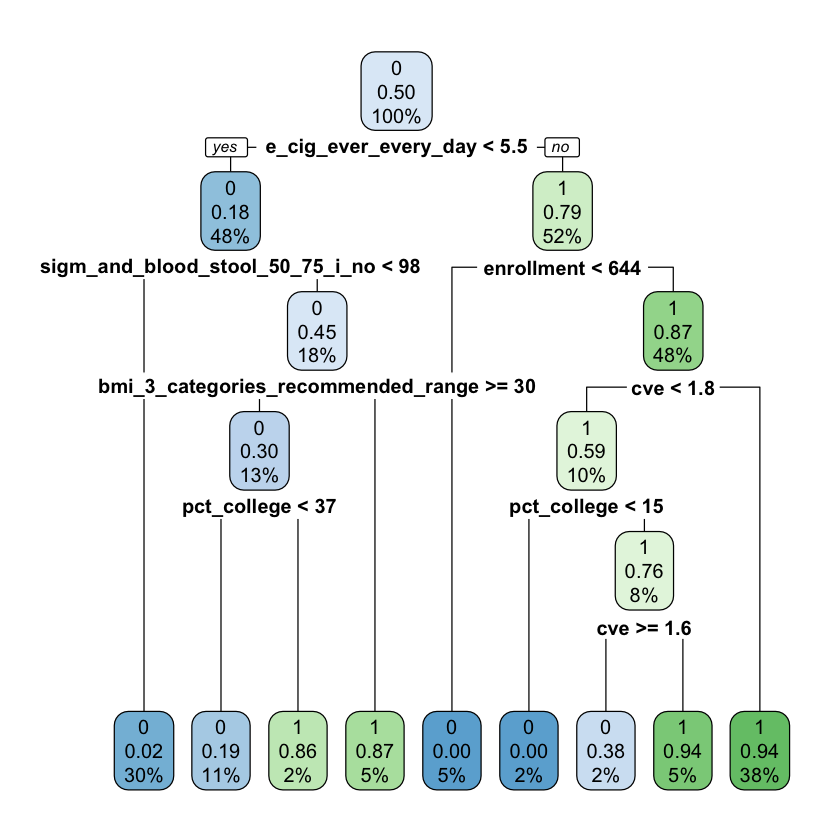

In [184]:

fit <- rpart(outbreak ~ ., data = train_balanced, method = "class")
rpart.plot(fit)

pred <- predict(fit, newdata = test, type = "class")

evaluation_table <- table(Actual = test$outbreak, Predicted = pred)

print(evaluation_table)

